=== Float Coefficients ===
b = 0.017406  0.061207  0.166164  0.255222  0.255222  0.166164  0.061207  0.017406
Sum of coefficients (DC gain): 1.000000
Max coefficient magnitude:     0.255222
Fs = 1000.000 Hz,  Fc = 50.000 Hz,  Nyquist = 500.000 Hz

=== Int8 Quantised Coefficients ===
Scaled (x128):     2.23     7.83    21.27    32.67    32.67    21.27     7.83     2.23
Rounded int8:         2        8       21       33       33       21        8        2
Requantised:     0.0156   0.0625   0.1641   0.2578   0.2578   0.1641   0.0625   0.0156

Quantisation error per tap:
   0.001781  -0.001293  0.002102  -0.002591  -0.002591  0.002102  -0.001293  0.001781
Max absolute error: 0.002591
RMS error:          0.001998

=== Filter Performance ===
                     Float       Int8
Passband ripple:    0.883 dB    0.868 dB
Stopband atten:      3.61 dB     3.55 dB
Performance loss:   -0.02 dB


=== Time Domain SNR ===
Input SNR (signal vs noise):    0.03 dB
Float filtered SNR:             4.72 dB

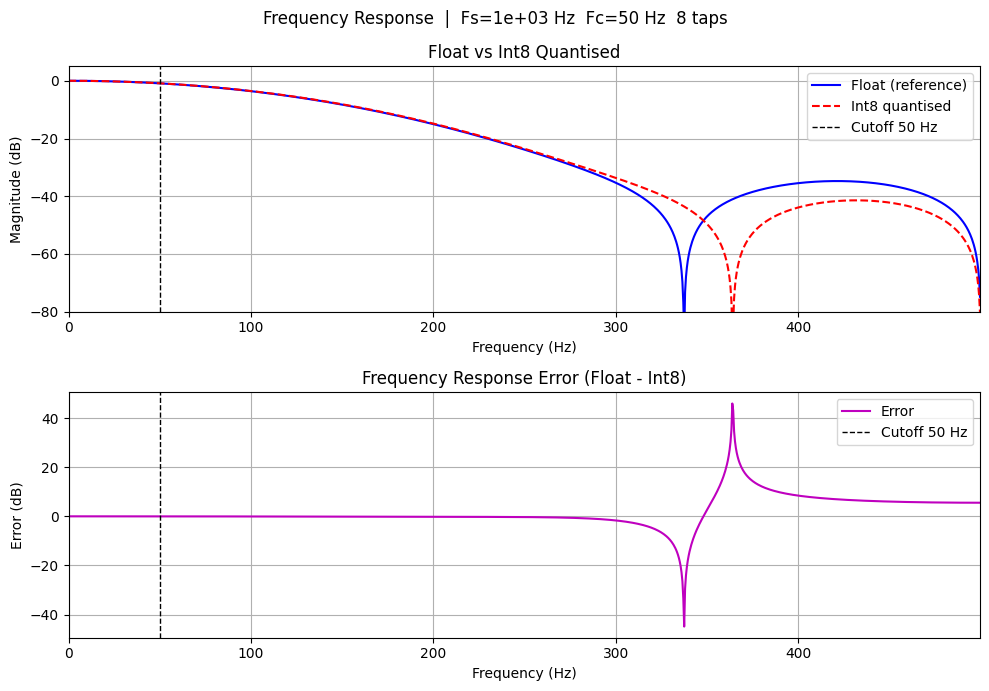

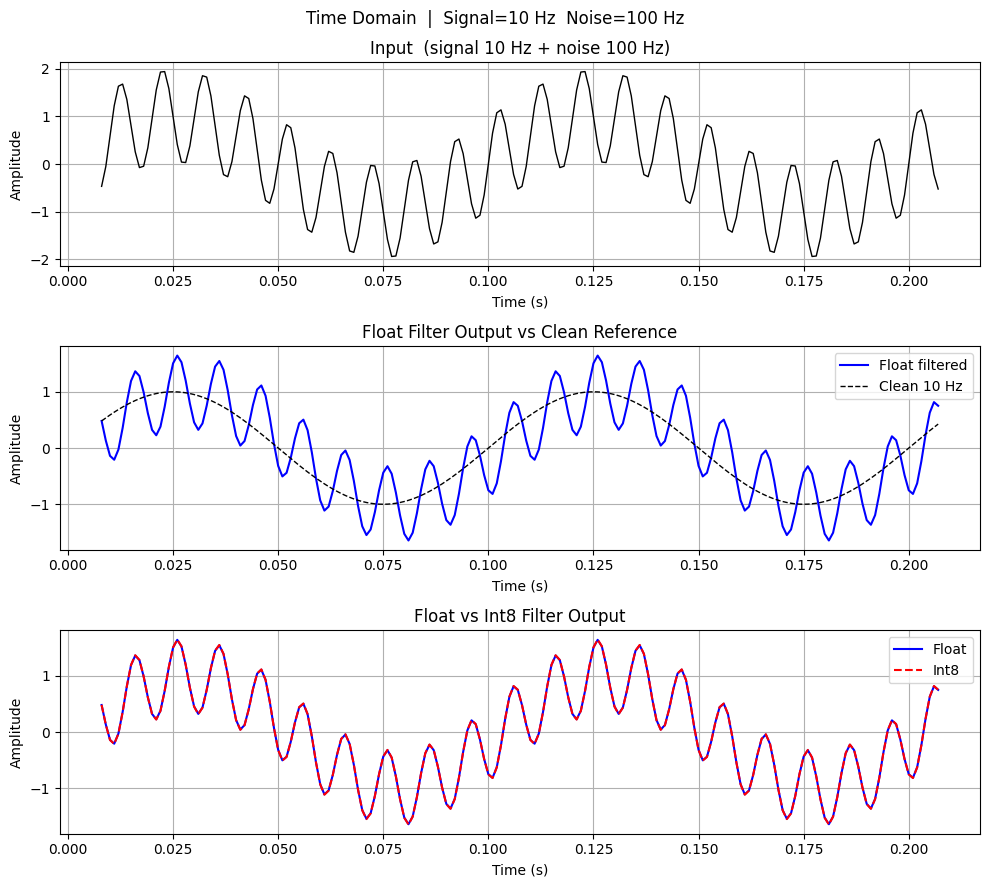

In [4]:
# ============================================================
#  FIR Low-Pass Filter Design & Int8 Quantisation Analysis
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, freqz

def fir_filt_linear_buff(b, x, z):
    y = np.zeros(len(x))
    z = z.copy()
    for n in range(len(x)):
        z    = np.concatenate(([x[n]], z[:-1]))
        y[n] = b @ z
    return y

def export_c_header(filename, b_int8, b_float, Fs, Fc, N_taps, scale):
    f_div, f_unit = freq_scale(Fs)
    with open(filename, 'w') as f:
        f.write('#ifndef FIR_COEFFS_H\n')
        f.write('#define FIR_COEFFS_H\n\n')
        f.write('#include <stdint.h>\n\n')
        f.write(f'/* FIR Low-Pass Filter Coefficients\n')
        f.write(f' * Fs     = {Fs/f_div:.3g} {f_unit}\n')
        f.write(f' * Fc     = {Fc/f_div:.3g} {f_unit}\n')
        f.write(f' * Taps   = {N_taps}\n')
        f.write(f' * Format = Q1.7 (int8, scale = {scale})\n')
        f.write(f' * To recover float: coeff / {scale}.0f\n')
        f.write(f' *\n * Float reference:\n *   ')
        f.write('  '.join(f'{x:.6f}' for x in b_float))
        f.write('\n */\n\n')
        f.write(f'#define N_TAPS  {N_taps}\n')
        f.write(f'#define Q_SCALE {scale}\n\n')
        for k in range(N_taps):
            val     = int(b_int8[k])
            hex_val = format(val & 0xFF, '02X')
            recovered = val / scale
            f.write(f'#define COEFF_{k}  0x{hex_val}  '
                    f'/* {val:4d} -> {recovered:+.6f}  '
                    f'(float: {b_float[k]:+.6f}) */\n')
        f.write('\nstatic const int8_t fir_coeffs[N_TAPS] = {\n    ')
        f.write(',\n    '.join(
            f'(int8_t)COEFF_{k}  /* {int(b_int8[k]):4d} */'
            for k in range(N_taps)
        ))
        f.write('\n};\n\n')
        f.write('/*\n * Verilog testbench load sequence\n')
        f.write(' * Send coeff[7] first, coeff[0] last\n *\n')
        b_reversed = b_int8[::-1]
        for k in range(N_taps):
            hex_val = format(int(b_reversed[k]) & 0xFF, '02X')
            f.write(f" * cycle {k+1} : send 8'h{hex_val}"
                    f'  (coeff[{N_taps-1-k}] = {int(b_reversed[k])})\n')
        f.write(' */\n\n#endif /* FIR_COEFFS_H */\n')
    print(f'C header written to {filename}')

# ============================================================
#  1. FILTER DESIGN
# ============================================================

Fs     = 1000   # Sampling frequency (Hz) — change freely
Fc     = 50    # Cutoff frequency (Hz)   — change freely
N_taps = 8      # Number of taps

# Signal at 10% of Fc (should pass), noise at 4x Fc (should be blocked)
f_signal = Fc * 0.2
f_noise  = Fc * 2

# ---- Dynamic frequency axis scaling -------------------------
def freq_scale(Fs):
    """Return (divisor, unit_string) based on Nyquist frequency."""
    nyq = Fs / 2
    if nyq >= 1e6:
        return 1e6, 'MHz'
    elif nyq >= 1e3:
        return 1e3, 'kHz'
    else:
        return 1.0, 'Hz'

def time_scale(duration):
    """Return (divisor, unit_string) based on signal duration."""
    if duration < 1e-3:
        return 1e-6, 'µs'
    elif duration < 1:
        return 1e-3, 'ms'
    else:
        return 1.0, 's'

f_div, f_unit = freq_scale(Fs)
# -------------------------------------------------------------

b_float = firwin(N_taps, Fc, window='hamming', fs=Fs)

print('=== Float Coefficients ===')
print('b =', '  '.join(f'{x:.6f}' for x in b_float))
print(f'Sum of coefficients (DC gain): {np.sum(b_float):.6f}')
print(f'Max coefficient magnitude:     {np.max(np.abs(b_float)):.6f}')
print(f'Fs = {Fs/f_div:.3f} {f_unit},  '
      f'Fc = {Fc/f_div:.3f} {f_unit},  '
      f'Nyquist = {(Fs/2)/f_div:.3f} {f_unit}\n')

# ============================================================
#  2. INT8 QUANTISATION
# ============================================================

scale       = 128
b_scaled    = b_float * scale
b_int8      = np.round(b_scaled).astype(np.int8)
b_quantised = b_int8.astype(np.float64) / scale

print('=== Int8 Quantised Coefficients ===')
print('Scaled (x128): ', '  '.join(f'{x:7.2f}' for x in b_scaled))
print('Rounded int8:  ', '  '.join(f'{x:7d}'   for x in b_int8))
print('Requantised:   ', '  '.join(f'{x:7.4f}' for x in b_quantised))

quant_error = b_float - b_quantised
print('\nQuantisation error per tap:')
print('  ', '  '.join(f'{x:8.6f}' for x in quant_error))
print(f'Max absolute error: {np.max(np.abs(quant_error)):.6f}')
print(f'RMS error:          {np.sqrt(np.mean(quant_error**2)):.6f}\n')

# ============================================================
#  3. FREQUENCY RESPONSE COMPARISON
# ============================================================

NFFT = 1024
f,  H_float = freqz(b_float,     1, worN=NFFT, fs=Fs)
_,  H_int8  = freqz(b_quantised, 1, worN=NFFT, fs=Fs)

H_float_db = 20 * np.log10(np.abs(H_float) + np.finfo(float).eps)
H_int8_db  = 20 * np.log10(np.abs(H_int8)  + np.finfo(float).eps)

# Scale frequency axis
f_plot = f / f_div
Fc_plot = Fc / f_div

fig, axes = plt.subplots(2, 1, figsize=(10, 7))
fig.suptitle(f'Frequency Response  |  Fs={Fs/f_div:.3g} {f_unit}  '
             f'Fc={Fc/f_div:.3g} {f_unit}  {N_taps} taps')

axes[0].plot(f_plot, H_float_db, 'b-',  linewidth=1.5, label='Float (reference)')
axes[0].plot(f_plot, H_int8_db,  'r--', linewidth=1.5, label='Int8 quantised')
axes[0].axvline(x=Fc_plot, color='k', linestyle='--', linewidth=1,
                label=f'Cutoff {Fc/f_div:.3g} {f_unit}')
axes[0].set_ylim([-80, 5])
axes[0].set_xlim([0, f_plot[-1]])
axes[0].set_xlabel(f'Frequency ({f_unit})')
axes[0].set_ylabel('Magnitude (dB)')
axes[0].set_title('Float vs Int8 Quantised')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(f_plot, H_float_db - H_int8_db, 'm-', linewidth=1.5, label='Error')
axes[1].axvline(x=Fc_plot, color='k', linestyle='--', linewidth=1,
                label=f'Cutoff {Fc/f_div:.3g} {f_unit}')
axes[1].set_xlim([0, f_plot[-1]])
axes[1].set_xlabel(f'Frequency ({f_unit})')
axes[1].set_ylabel('Error (dB)')
axes[1].set_title('Frequency Response Error (Float - Int8)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()

# ============================================================
#  4. STOPBAND ANALYSIS
# ============================================================

passband_idx = f <= Fc
stopband_idx = f >= (2 * Fc)

pb_ripple_float = np.max(H_float_db[passband_idx]) - np.min(H_float_db[passband_idx])
pb_ripple_int8  = np.max(H_int8_db[passband_idx])  - np.min(H_int8_db[passband_idx])
sb_atten_float  = -np.max(H_float_db[stopband_idx])
sb_atten_int8   = -np.max(H_int8_db[stopband_idx])

print('=== Filter Performance ===')
print(f'                     Float       Int8')
print(f'Passband ripple:   {pb_ripple_float:6.3f} dB   {pb_ripple_int8:6.3f} dB')
print(f'Stopband atten:    {sb_atten_float:6.2f} dB   {sb_atten_int8:6.2f} dB')
print(f'Performance loss:  {pb_ripple_int8 - pb_ripple_float:6.2f} dB\n')

# ============================================================
#  5. TIME DOMAIN TEST — SIGNAL + NOISE
# ============================================================


# Duration: show at least 10 cycles of the signal frequency
duration = max(10 / f_signal, 500 / Fs)
t        = np.arange(0, duration, 1/Fs)
t_div, t_unit = time_scale(duration)

x_clean  = np.sin(2 * np.pi * f_signal * t)
x_noise  = np.sin(2 * np.pi * f_noise  * t)
x_input  = x_clean + x_noise

y_float = fir_filt_linear_buff(b_float,     x_input, np.zeros(N_taps))
y_int8  = fir_filt_linear_buff(b_quantised, x_input, np.zeros(N_taps))

trim     = N_taps
t_plot   = t[trim:] / t_div
x_plot   = x_input[trim:]
y_f_plot = y_float[trim:]
y_i_plot = y_int8[trim:]

# Only show first 200 samples to keep plots readable at any sample rate
view = min(200, len(t_plot))

fig, axes = plt.subplots(3, 1, figsize=(10, 9))
fig.suptitle(f'Time Domain  |  Signal={f_signal/f_div:.3g} {f_unit}  '
             f'Noise={f_noise/f_div:.3g} {f_unit}')

axes[0].plot(t_plot[:view], x_plot[:view], 'k', linewidth=1)
axes[0].set_title(f'Input  (signal {f_signal/f_div:.3g} {f_unit}'
                  f' + noise {f_noise/f_div:.3g} {f_unit})')
axes[0].set_xlabel(f'Time ({t_unit})')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True)

axes[1].plot(t_plot[:view], y_f_plot[:view],       'b',   linewidth=1.5,
             label='Float filtered')
axes[1].plot(t_plot[:view], x_clean[trim:trim+view], 'k--', linewidth=1,
             label=f'Clean {f_signal/f_div:.3g} {f_unit}')
axes[1].set_title('Float Filter Output vs Clean Reference')
axes[1].set_xlabel(f'Time ({t_unit})')
axes[1].set_ylabel('Amplitude')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(t_plot[:view], y_f_plot[:view], 'b',   linewidth=1.5, label='Float')
axes[2].plot(t_plot[:view], y_i_plot[:view], 'r--', linewidth=1.5, label='Int8')
axes[2].set_title('Float vs Int8 Filter Output')
axes[2].set_xlabel(f'Time ({t_unit})')
axes[2].set_ylabel('Amplitude')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()

# ============================================================
#  6. SNR COMPARISON
# ============================================================

def rms(x):
    return np.sqrt(np.mean(x**2))

ref       = x_clean[trim:]
snr_input = 20 * np.log10(rms(x_clean[trim:]) / rms(x_noise[trim:]))
snr_float = 20 * np.log10(rms(y_f_plot) / rms(y_f_plot - ref))
snr_int8  = 20 * np.log10(rms(y_i_plot) / rms(y_i_plot - ref))

print('\n=== Time Domain SNR ===')
print(f'Input SNR (signal vs noise):  {snr_input:6.2f} dB')
print(f'Float filtered SNR:           {snr_float:6.2f} dB')
print(f'Int8 filtered SNR:            {snr_int8:6.2f} dB')
print(f'SNR loss due to quantisation: {snr_float - snr_int8:6.2f} dB')

# ============================================================
#  7. EXPORT COEFFICIENTS
# ============================================================

with open('fir_coeffs.v', 'w') as fid:
    fid.write(f'// FIR Coefficients — Fs={Fs/f_div:.3g}{f_unit} '
              f'Fc={Fc/f_div:.3g}{f_unit} {N_taps} taps Q1.7\n')
    fid.write('// Float reference: ' + '  '.join(f'{x:.6f}' for x in b_float) + '\n\n')
    fid.write('// Verilog localparams\n')
    for k in range(N_taps):
        fid.write(f"localparam signed [7:0] COEFF_{k} = 8'sd{b_int8[k]};\n")
    fid.write('\n// Testbench load sequence (coeff[7] first, coeff[0] last)\n')
    b_reversed = b_int8[::-1]
    for k in range(N_taps):
        hex_val = format(int(b_reversed[k]) & 0xFF, '02X')
        fid.write(f"// cycle {k+1} : send 8'h{hex_val}  "
                  f"(coeff[{N_taps-1-k}] = {b_reversed[k]})\n")

print('\nCoefficients written to coefficients.txt')
export_c_header('fir_coeffs.h', b_int8, b_float, Fs, Fc, N_taps, scale)

plt.show()

# ============================================================
#  8. HELPER FUNCTIONS
# ============================================================

